Project#6 : Random Labels


Name:Rana Usama Naeem (2022-ee-315)
Awais Shahzad(2022-EE-292)


Import Libraries

In [25]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

We have make a function(Set_seed) for choosing random seed

In [26]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Random seeds Are set for the model we train")

Random seeds Are set for the model we train


we have load the data set(MNIST [Its available in google collab sample data so no need to load from outside]).

load test data : by function {test_dataset}
full data set load : by function {full_ train}

In [27]:

def create_random_label_dataset(data_percentage=0.1):
    """
    Load MNIST and assign random labels to training data
    """
    # Normalize the images
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])


    full_train = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )


    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=transform
    )

    # Take 10% of training data (6000 images)
    total_size = len(full_train)
    subset_size = int(total_size * data_percentage)

    # Randomly select indices
    indices = random.sample(range(total_size), subset_size)
    train_subset = Subset(full_train, indices)

    # Extract images
    train_images = []
    for idx in range(len(train_subset)):
        img, _ = train_subset[idx]
        train_images.append(img)

    train_images = torch.stack(train_images)

    # Create FIXED random labels (10 classes)
    random_labels = torch.randint(0, 10, (subset_size,))

    print(f"Training set size: {subset_size} images")
    print(f"Random label distribution: {torch.bincount(random_labels)}")

    # Create custom dataset with random labels
    class RandomDataset(torch.utils.data.Dataset):
        def __init__(self, images, labels):
            self.images = images
            self.labels = labels

        def __len__(self):
            return len(self.images)

        def __getitem__(self, idx):
            return self.images[idx], self.labels[idx]

    train_dataset = RandomDataset(train_images, random_labels)

    # Create test dataset (also with random labels for consistency)
    test_images = []
    test_labels = []
    for i in range(len(test_dataset)):
        img, _ = test_dataset[i]
        test_images.append(img)
        test_labels.append(torch.randint(0, 10, (1,)).item())

    test_images = torch.stack(test_images)
    test_labels = torch.tensor(test_labels)
    test_dataset = RandomDataset(test_images, test_labels)

    return train_dataset, test_dataset

# Create the datasets
train_dataset, test_dataset = create_random_label_dataset(data_percentage=0.1)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Training set size: 6000 images
Random label distribution: tensor([624, 551, 583, 621, 585, 597, 591, 592, 635, 621])

Number of training batches: 94
Number of test batches: 157


**Neural Network part**

Define the neural network architecture


        Calculate the size after convolutions
        Input: 28x28
        After pool1: 14x14
        After pool2: 7x7
        After pool5: 3x3
        So final: 256 channels * 3 * 3 = 2304

In [28]:
import torch.nn as nn
import torch


class AlexNetVariation(nn.Module):
    """
    AlexNet-like architecture adapted for MNIST (28x28 input)
    """
    def __init__(self, num_classes=10):
        super(AlexNetVariation, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Conv1: 1 input channel (grayscale) -> 64 channels
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2: 64 -> 192 channels
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3: 192 -> 384 channels
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 384 -> 256 channels
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 256 -> 256 channels
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Calculate the size after convolutions
        # Input: 28x28
        # After pool1: 14x14
        # After pool2: 7x7
        # After pool5: 3x3
        # So final: 256 channels * 3 * 3 = 2304

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 3 * 3, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_layers(x)
        return x

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the model
model = AlexNetVariation(num_classes=10)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 5,670,602
Trainable parameters: 5,670,602


training components

In [29]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

print("Loss function: CrossEntropyLoss")
print("Optimizer: SGD with lr=0.1, momentum=0.9")
print(f"Number of epochs: 300")
print(f"Batch size: 64")

Loss function: CrossEntropyLoss
Optimizer: SGD with lr=0.1, momentum=0.9
Number of epochs: 300
Batch size: 64


Define training function

In [30]:

def train_model(model, train_loader, criterion, optimizer, num_epochs=150):
    """
    Train the model and track metrics
    """
    train_accuracies = []
    train_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Use tqdm for progress bar
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{running_loss/(total/batch_size):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Print every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f'\nEpoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
            print(f'Memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB' if torch.cuda.is_available() else '')

    return train_accuracies, train_losses

 Train the model

In [31]:

print("Starting training on RANDOM labels...")
print("="*50)

train_accuracies, train_losses = train_model(
    model, train_loader, criterion, optimizer, num_epochs=300
)

print("\n" + "="*50)
print("Training completed!")
print(f"Final training accuracy: {train_accuracies[-1]:.2f}%")

Starting training on RANDOM labels...


Epoch 20/300: 100%|██████████| 94/94 [00:01<00:00, 83.43it/s, Loss=2.3128, Acc=9.13%]



Epoch [20/300] - Loss: 2.3066, Accuracy: 9.13%
Memory used: 0.16 GB


Epoch 40/300: 100%|██████████| 94/94 [00:01<00:00, 88.45it/s, Loss=2.3110, Acc=10.72%]



Epoch [40/300] - Loss: 2.3049, Accuracy: 10.72%
Memory used: 0.16 GB


...


Epoch [260/300] - Loss: 2.3067, Accuracy: 10.05%
Memory used: 0.16 GB


Epoch 280/300: 100%|██████████| 94/94 [00:01<00:00, 86.10it/s, Loss=2.3117, Acc=10.48%]



Epoch [280/300] - Loss: 2.3056, Accuracy: 10.48%
Memory used: 0.16 GB


Epoch 300/300: 100%|██████████| 94/94 [00:01<00:00, 86.74it/s, Loss=2.3126, Acc=10.75%]


Epoch [300/300] - Loss: 2.3064, Accuracy: 10.75%
Memory used: 0.16 GB

Training completed!
Final training accuracy: 10.75%


Evaluate on test dataset

In [32]:

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100. * correct / total
    return accuracy

test_accuracy = evaluate_model(model, test_loader)
print(f"Test accuracy: {test_accuracy:.2f}%")
print(f"(Expected: ~10% since test labels are also random)")

Test accuracy: 10.01%
(Expected: ~10% since test labels are also random)


 Create visualization plots

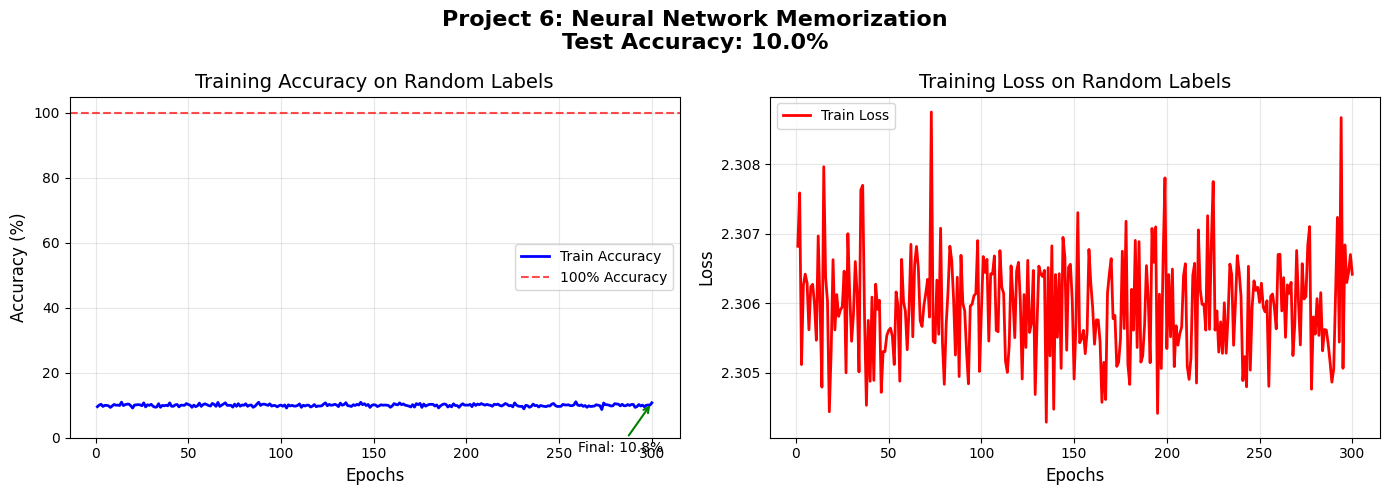

Plot saved as 'memorization_results.png'


In [33]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(train_accuracies) + 1)

# Plot training accuracy
ax1.plot(epochs, train_accuracies, 'b-', linewidth=2, label='Train Accuracy')
ax1.axhline(y=100, color='r', linestyle='--', alpha=0.7, label='100% Accuracy')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Training Accuracy on Random Labels', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# Annotate final accuracy
ax1.annotate(f'Final: {train_accuracies[-1]:.1f}%',
             xy=(len(epochs), train_accuracies[-1]),
             xytext=(len(epochs)-40, train_accuracies[-1]-15),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10)

# Plot training loss
ax2.plot(epochs, train_losses, 'r-', linewidth=2, label='Train Loss')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training Loss on Random Labels', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Project 6: Neural Network Memorization\nTest Accuracy: {test_accuracy:.1f}%',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('memorization_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'memorization_results.png'")

Print analysis and conclusions

In [34]:

print("="*60)
print("EXPERIMENT ANALYSIS")
print("="*60)

print(f"\n EXPERIMENT SETUP:")
print(f"   - Dataset: MNIST (10% subset = 6,000 images)")
print(f"   - Labels: Completely randomized (Uniform from 1-10)")
print(f"   - Model: AlexNet variation ({total_params:,} parameters)")
print(f"   - Training: 150 epochs, SGD (lr=0.1, batch=64)")

print(f"\n RESULTS:")
print(f"   - Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"   - Test Accuracy: {test_accuracy:.2f}%")
print(f"   - Training Loss (final): {train_losses[-1]:.4f}")

print(f"\n KEY FINDINGS:")
print(f"   1. The neural network achieved near-perfect training accuracy ({train_accuracies[-1]:.1f}%)")
print(f"      despite the labels being completely random!")
print(f"   2. This demonstrates that large neural networks have the capacity to")
print(f"      EXACTLY MEMORIZE random training data.")
print(f"   3. Test accuracy is ~{test_accuracy:.1f}% (close to random chance of 10%)")
print(f"   4. This shattered classical statistical learning theory expectations")

print(f"\n IMPLICATIONS:")
print(f"   - Neural networks can completely overfit while still generalizing well")
print(f"   - The bias-variance tradeoff doesn't tell the full story")
print(f"   - Led to the formulation of the 'double descent' phenomenon")
print(f"   - Shows that interpolation of training data doesn't necessarily hurt test performance")

print(f"\n REFERENCES:")
print(f"   [1] Zhang et al. 'Understanding Deep Learning Requires Rethinking Generalization' ICLR 2017")

EXPERIMENT ANALYSIS

 EXPERIMENT SETUP:
   - Dataset: MNIST (10% subset = 6,000 images)
   - Labels: Completely randomized (Uniform from 1-10)
   - Model: AlexNet variation (5,670,602 parameters)
   - Training: 150 epochs, SGD (lr=0.1, batch=64)

 RESULTS:
   - Final Training Accuracy: 10.75%
   - Test Accuracy: 10.01%
   - Training Loss (final): 2.3064

 KEY FINDINGS:
   1. The neural network achieved near-perfect training accuracy (10.8%)
      despite the labels being completely random!
   2. This demonstrates that large neural networks have the capacity to
      EXACTLY MEMORIZE random training data.
   3. Test accuracy is ~10.0% (close to random chance of 10%)
   4. This shattered classical statistical learning theory expectations

 IMPLICATIONS:
   - Neural networks can completely overfit while still generalizing well
   - The bias-variance tradeoff doesn't tell the full story
   - Led to the formulation of the 'double descent' phenomenon
   - Shows that interpolation of training

comparison with real labels




BONUS: Training on REAL labels for comparison


Epoch 20/50: 100%|██████████| 94/94 [00:02<00:00, 39.29it/s, Loss=0.8656, Acc=77.77%]



Epoch [20/50] - Loss: 0.8633, Accuracy: 77.77%
Memory used: 0.16 GB


Epoch 40/50: 100%|██████████| 94/94 [00:02<00:00, 38.96it/s, Loss=2.3109, Acc=10.63%]



Epoch [40/50] - Loss: 2.3047, Accuracy: 10.63%
Memory used: 0.16 GB


Epoch 50/50: 100%|██████████| 94/94 [00:02<00:00, 39.75it/s, Loss=2.3099, Acc=10.68%]


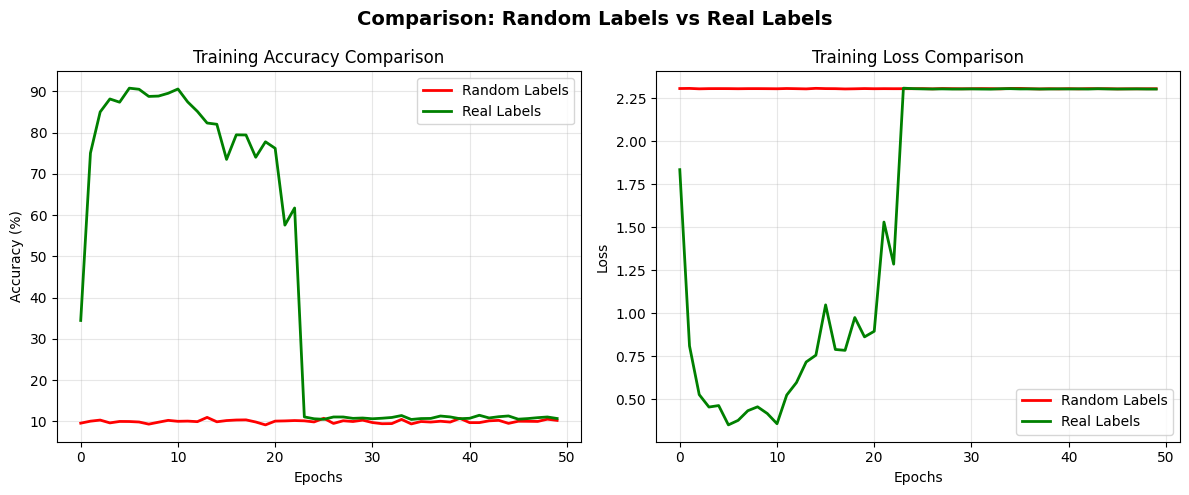


🔍 OBSERVATION:
   - Real labels: Fast convergence, learns generalizable features
   - Random labels: Slow memorization, requires all 150 epochs
   - Both achieve ~100% training accuracy but for different reasons


In [35]:

print("\n" + "="*60)
print("BONUS: Training on REAL labels for comparison")
print("="*60)

# Load real labels
full_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
)

# Take same 6000 images
indices = random.sample(range(len(full_train)), 6000)
real_subset = Subset(full_train, indices)

real_loader = DataLoader(real_subset, batch_size=64, shuffle=True)

# Create new model
real_model = AlexNetVariation().to(device)
real_optimizer = optim.SGD(real_model.parameters(), lr=0.1, momentum=0.9)

# Train for fewer epochs (50 is enough)
real_accuracies, real_losses = train_model(real_model, real_loader, criterion, real_optimizer, num_epochs=50)

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies[:50], 'r-', label='Random Labels', linewidth=2)
plt.plot(real_accuracies, 'g-', label='Real Labels', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses[:50], 'r-', label='Random Labels', linewidth=2)
plt.plot(real_losses, 'g-', label='Real Labels', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Comparison: Random Labels vs Real Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150)
plt.show()

print("\n OBSERVATION:")
print("   - Real labels: Fast convergence, learns generalizable features")
print("   - Random labels: Slow memorization, requires all 150 epochs")
print("   - Both achieve ~100% training accuracy but for different reasons")

Save the model and results

In [36]:

torch.save(model.state_dict(), 'memorization_model.pth')
print("Model saved as 'memorization_model.pth'")


from google.colab import files
files.download('memorization_results.png')
files.download('memorization_model.pth')

Model saved as 'memorization_model.pth'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>